# 02 — Exploratory analysis

The purpose here is not to look for a signal. It is to establish what could
produce a signal *other than* Parkinson's disease, and to make the structure
that drives the leakage experiment visible.

Three questions:

1. Are the groups comparable on age and sex, or would a model with no access to
   voice already separate them?
2. How many recordings does each participant contribute, and is that number
   related to the label?
3. Is recording duration itself informative — a property of the session rather
   than of the voice?

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import soundfile as sf

# Walk up to the repository root so this runs identically from notebooks/,
# scripts/, or the repository root itself.
ROOT = Path.cwd().resolve()
while not (ROOT / "requirements.txt").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src import viz as V  # noqa: E402

V.use_house_style()
pd.set_option("display.width", 140)

meta = pd.read_parquet(ROOT / "data" / "processed" / "metadata.parquet")
cohort = meta[meta["group"].isin(["PD", "eHC"])].copy()
participants = cohort.drop_duplicates("subject_id")
print(f"{len(cohort)} recordings from {len(participants)} participants")

786 recordings from 47 participants


## Figure 1 — Age and sex, including the excluded young controls

The left panel is the reason young controls are excluded: they do not overlap
the PD age range at all. The right panel is the confounder that *does* survive
into the analysis cohort.

  saved fig01_demographics.png (+ .pdf)


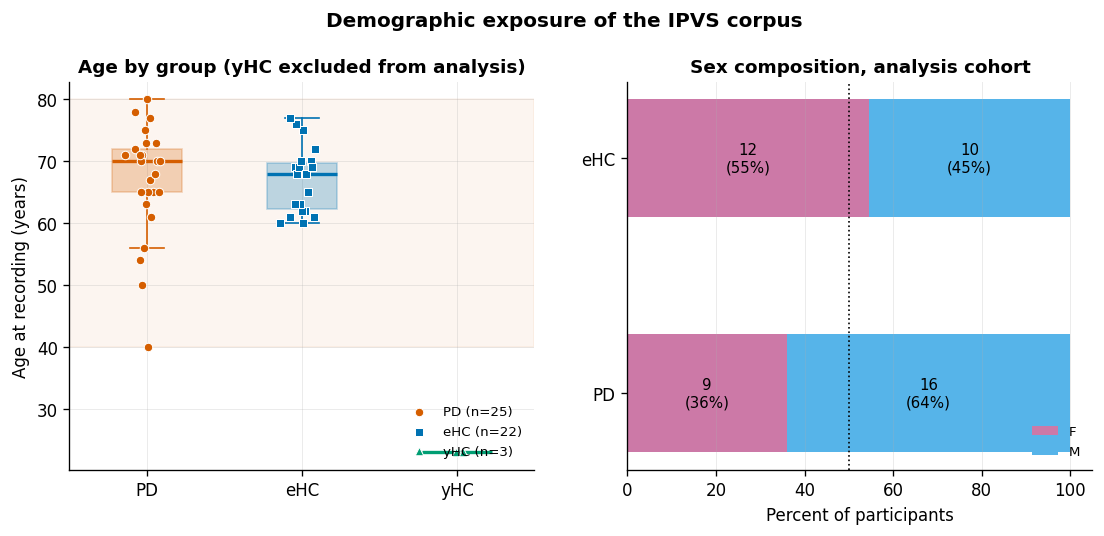

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

all_participants = meta.drop_duplicates("subject_id")
groups = {
    g: all_participants.loc[all_participants["group"] == g, "age"].tolist()
    for g in ("PD", "eHC", "yHC")
}
V.raincloud(axes[0], groups, "Age at recording (years)")
axes[0].axhspan(
    min(groups["PD"]), max(groups["PD"]), color="#D55E00", alpha=0.06, zorder=0
)
axes[0].set_title("Age by group (yHC excluded from analysis)")
axes[0].legend(loc="lower right", fontsize=8)

sex_mix = (
    participants.groupby(["group", "sex"]).size().unstack(fill_value=0).loc[["PD", "eHC"]]
)
sex_pct = 100 * sex_mix.div(sex_mix.sum(axis=1), axis=0)
bottom = np.zeros(len(sex_pct))
for sex, colour in (("F", "#CC79A7"), ("M", "#56B4E9")):
    axes[1].barh(
        sex_pct.index, sex_pct[sex], left=bottom, color=colour, label=f"{sex}", height=0.5
    )
    for i, (value, base) in enumerate(zip(sex_pct[sex], bottom)):
        axes[1].text(
            base + value / 2,
            i,
            f"{sex_mix[sex].iloc[i]}\n({value:.0f}%)",
            ha="center",
            va="center",
            fontsize=9,
        )
    bottom = bottom + sex_pct[sex].to_numpy()
axes[1].axvline(50, color="black", linestyle=":", linewidth=1)
axes[1].set_xlabel("Percent of participants")
axes[1].set_title("Sex composition, analysis cohort")
axes[1].legend(loc="lower right", fontsize=8)
axes[1].grid(axis="y", visible=False)

fig.suptitle(
    "Demographic exposure of the IPVS corpus", fontsize=12, fontweight="bold", y=1.02
)
V.save_fig(
    fig,
    "fig01_demographics",
    "Age and sex by group. Young controls do not overlap the PD age range and "
    "are excluded. In the analysis cohort age is closely matched but sex is not.",
)
plt.show()

In [3]:
summary = (
    participants.groupby("group")
    .agg(
        n=("subject_id", "size"),
        age_mean=("age", "mean"),
        age_sd=("age", "std"),
        age_range=("age", lambda s: f"{s.min()}-{s.max()}"),
        n_male=("sex", lambda s: int((s == "M").sum())),
        pct_male=("sex", lambda s: 100 * (s == "M").mean()),
    )
    .round(1)
)
print(summary.to_string())

# Two-sample tests, reported so the matching claim is not made by eye.
from scipy import stats  # noqa: E402

pd_age = participants.loc[participants["group"] == "PD", "age"]
hc_age = participants.loc[participants["group"] == "eHC", "age"]
t_stat, t_p = stats.ttest_ind(pd_age, hc_age, equal_var=False)
table = pd.crosstab(participants["group"], participants["sex"])
_, chi_p = stats.fisher_exact(table.to_numpy())

print(f"\nAge      : Welch t = {t_stat:+.2f}, p = {t_p:.3f}")
print(f"Sex      : Fisher exact p = {chi_p:.3f}")
print(
    "\nAge is matched (difference of well under a year). Sex is not balanced, so "
    "it must appear in the negative-control baseline."
)

        n  age_mean  age_sd age_range  n_male  pct_male
group                                                  
PD     25      66.8     9.1     40-80      16      64.0
eHC    22      67.1     5.2     60-77      10      45.5



Age      : Welch t = -0.14, p = 0.892
Sex      : Fisher exact p = 0.248

Age is matched (difference of well under a year). Sex is not balanced, so it must appear in the negative-control baseline.


## Figure 2 — Recordings per participant

This is the structural fact the whole experiment turns on. If a participant
contributes several recordings and the split is made at recording level, that
participant's own voice is in the training set when their held-out recording is
scored.

  saved fig02_recordings_per_participant.png (+ .pdf)


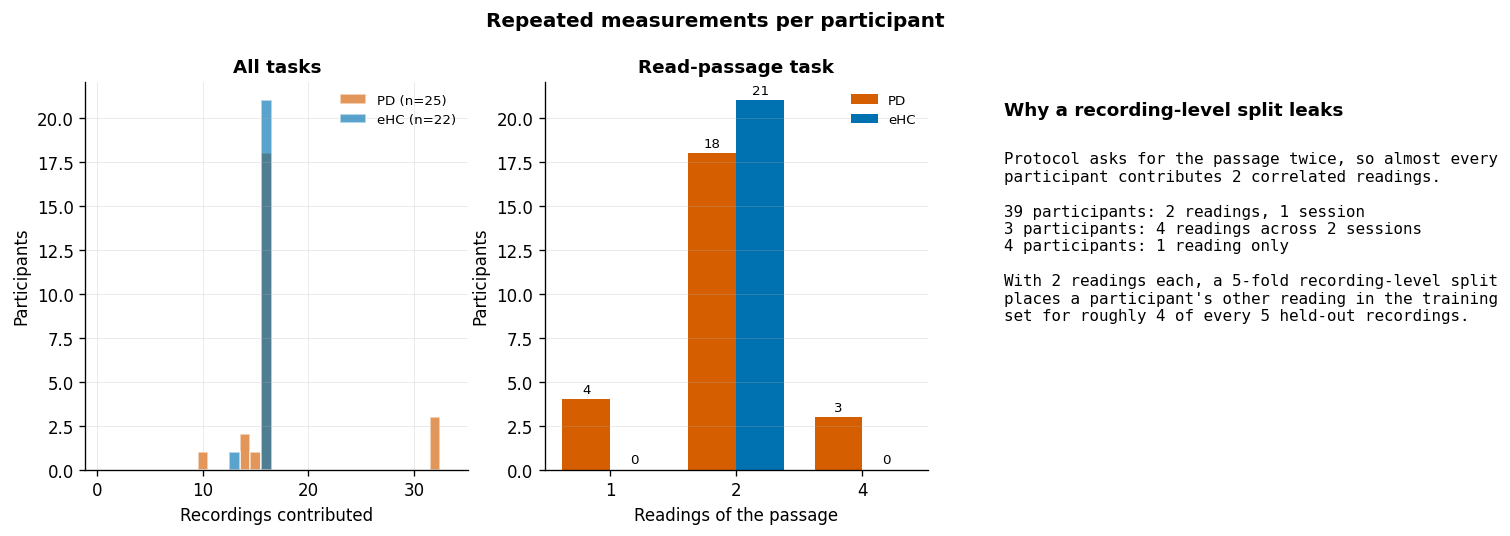

In [4]:
per_participant = (
    cohort.groupby(["group", "subject_id"])
    .agg(recordings=("path", "size"), sessions=("session_index", "nunique"))
    .reset_index()
)
read_text = cohort[cohort["task"] == "read_text"]
per_read = (
    read_text.groupby(["group", "subject_id"])
    .agg(readings=("path", "size"), sessions=("session_index", "nunique"))
    .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

for group in ("PD", "eHC"):
    values = per_participant.loc[per_participant["group"] == group, "recordings"]
    axes[0].hist(
        values,
        bins=np.arange(0.5, values.max() + 2.5),
        alpha=0.65,
        color=V.GROUP_COLOURS[group],
        label=f"{group} (n={len(values)})",
        edgecolor="white",
    )
axes[0].set_xlabel("Recordings contributed")
axes[0].set_ylabel("Participants")
axes[0].set_title("All tasks")
axes[0].legend(fontsize=8)

counts = (
    per_read.groupby(["group", "readings"]).size().unstack(fill_value=0).loc[["PD", "eHC"]]
)
x = np.arange(len(counts.columns))
width = 0.38
for i, group in enumerate(("PD", "eHC")):
    bars = axes[1].bar(
        x + (i - 0.5) * width,
        counts.loc[group],
        width,
        color=V.GROUP_COLOURS[group],
        label=group,
    )
    axes[1].bar_label(bars, fontsize=8, padding=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels(counts.columns)
axes[1].set_xlabel("Readings of the passage")
axes[1].set_ylabel("Participants")
axes[1].set_title("Read-passage task")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", visible=False)

multi = per_read[per_read["sessions"] > 1]
axes[2].axis("off")
axes[2].text(
    0.0,
    0.95,
    "Why a recording-level split leaks",
    fontsize=11,
    fontweight="bold",
    va="top",
)
lines = [
    f"Protocol asks for the passage twice, so almost every",
    f"participant contributes 2 correlated readings.",
    "",
    f"{(per_read['readings'] == 2).sum()} participants: 2 readings, 1 session",
    f"{len(multi)} participants: 4 readings across 2 sessions",
    f"{(per_read['readings'] == 1).sum()} participants: 1 reading only",
    "",
    "With 2 readings each, a 5-fold recording-level split",
    "places a participant's other reading in the training",
    "set for roughly 4 of every 5 held-out recordings.",
]
axes[2].text(0.0, 0.82, "\n".join(lines), fontsize=9.5, va="top", family="monospace")

fig.suptitle(
    "Repeated measurements per participant", fontsize=12, fontweight="bold", y=1.02
)
V.save_fig(
    fig,
    "fig02_recordings_per_participant",
    "Recordings per participant. The read-passage protocol produces two "
    "correlated readings per participant, and three PD participants were "
    "recorded in two separate sessions.",
)
plt.show()

## Figure 3 — Task completion, per participant

A missing recording is informative if it is missing for a reason related to the
label: a participant with more advanced disease may not complete every task.
That would let a model exploit *which* tasks exist rather than how they sound.

  saved fig03_task_completion.png (+ .pdf)


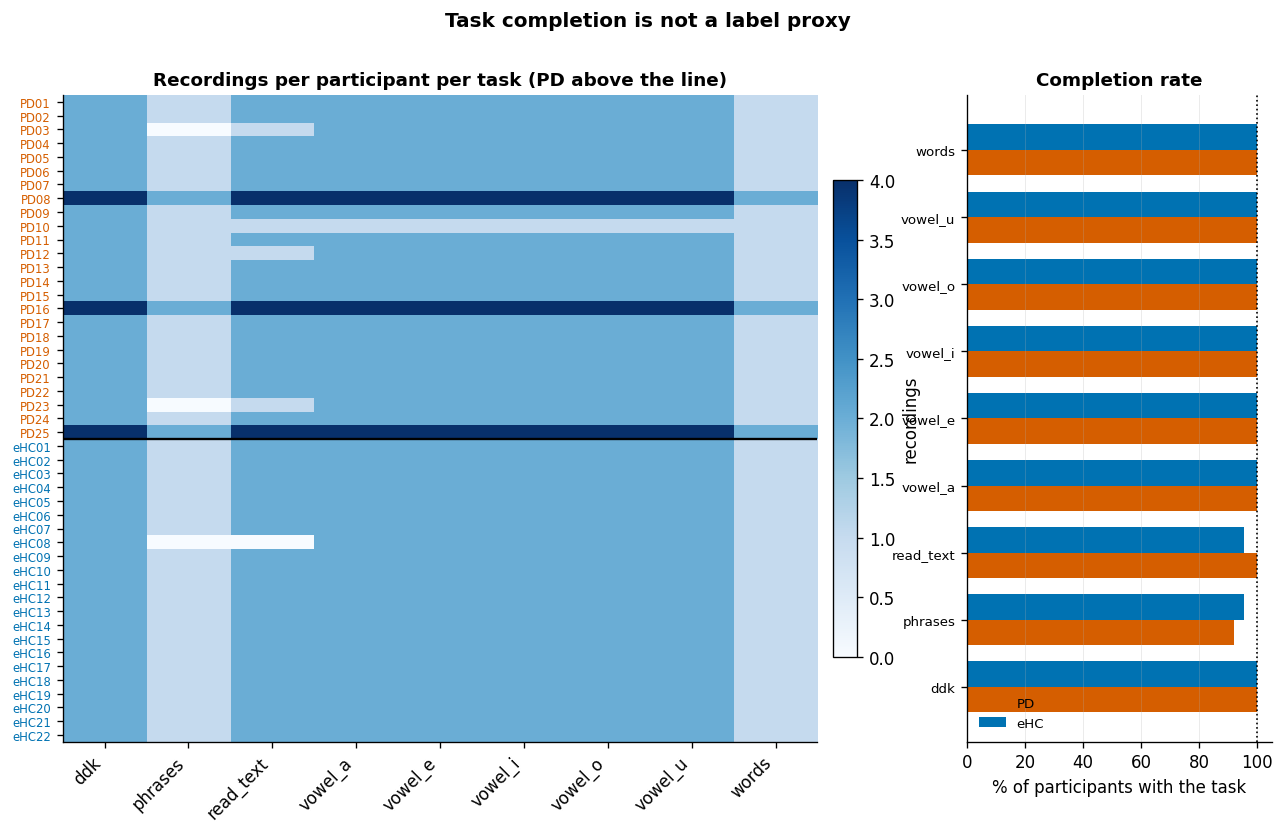

Completion rate (% of participants):
task     ddk  phrases  read_text  vowel_a  vowel_e  vowel_i  vowel_o  vowel_u  words
group                                                                               
PD     100.0     92.0      100.0    100.0    100.0    100.0    100.0    100.0  100.0
eHC    100.0     95.5       95.5    100.0    100.0    100.0    100.0    100.0  100.0


In [5]:
matrix = (
    cohort.pivot_table(
        index="subject_id", columns="task", values="path", aggfunc="count", fill_value=0
    )
)
order = cohort.drop_duplicates("subject_id").set_index("subject_id").loc[matrix.index]
matrix = matrix.loc[order.sort_values(["group", "subject_id"]).index]
row_groups = order.loc[matrix.index, "group"]

fig, axes = plt.subplots(
    1, 2, figsize=(13, 7), gridspec_kw={"width_ratios": [3, 1.15]}
)
im = axes[0].imshow(matrix.to_numpy(), aspect="auto", cmap="Blues", vmin=0, vmax=4)
axes[0].set_xticks(range(len(matrix.columns)))
axes[0].set_xticklabels(matrix.columns, rotation=45, ha="right")
axes[0].set_yticks(range(len(matrix)))
axes[0].set_yticklabels(
    [f"{sid}" for sid in matrix.index], fontsize=7
)
for tick, group in zip(axes[0].get_yticklabels(), row_groups):
    tick.set_color(V.GROUP_COLOURS[group])
boundary = (row_groups == "PD").sum()
axes[0].axhline(boundary - 0.5, color="black", linewidth=1.4)
axes[0].set_title("Recordings per participant per task (PD above the line)")
axes[0].grid(False)
fig.colorbar(im, ax=axes[0], label="recordings", fraction=0.03, pad=0.02)

completion = (matrix > 0).groupby(row_groups).mean() * 100
x = np.arange(len(completion.columns))
for i, group in enumerate(("PD", "eHC")):
    axes[1].barh(
        x + (i - 0.5) * 0.38,
        completion.loc[group],
        0.38,
        color=V.GROUP_COLOURS[group],
        label=group,
    )
axes[1].set_yticks(x)
axes[1].set_yticklabels(completion.columns, fontsize=8)
axes[1].set_xlabel("% of participants with the task")
axes[1].set_xlim(0, 105)
axes[1].axvline(100, color="black", linestyle=":", linewidth=1)
axes[1].set_title("Completion rate")
axes[1].legend(fontsize=8, loc="lower left")
axes[1].grid(axis="y", visible=False)

fig.suptitle(
    "Task completion is not a label proxy", fontsize=12, fontweight="bold", y=0.98
)
V.save_fig(
    fig,
    "fig03_task_completion",
    "Task completion per participant. Both groups complete the protocol at "
    "comparable rates, so missingness is not usable as a shortcut to the label.",
)
plt.show()

print("Completion rate (% of participants):")
print(completion.round(1).to_string())

## Figure 4 — Duration and level

Duration is a property of the session, not only of the speaker. If it separates
the groups, any model gets that separation free, so it is measured before any
acoustic feature is computed.

In [6]:
audio = cohort[
    ["subject_id", "group", "task", "duration", "samplerate", "channels", "subtype"]
].copy()

print("Recording format by group:")
print(
    audio.groupby(["group", "samplerate", "channels", "subtype"])
    .size()
    .rename("n")
    .to_frame()
    .to_string()
)

Recording format by group:
                                     n
group samplerate channels subtype     
PD    16000      1        PCM_16   277
      44100      1        PCM_16   160
eHC   16000      1        PCM_16   349


  saved fig04_duration.png (+ .pdf)


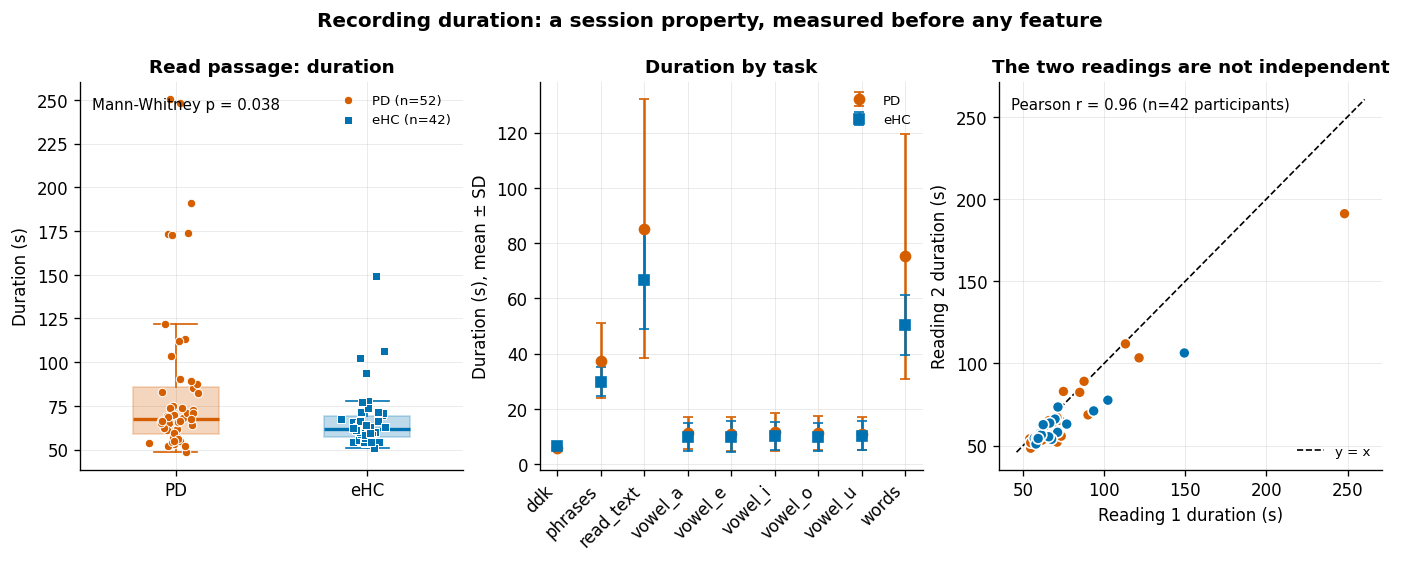


Within-participant duration correlation across the two readings: r = 0.961


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))

read_audio = audio[audio["task"] == "read_text"]
V.raincloud(
    axes[0],
    {g: read_audio.loc[read_audio["group"] == g, "duration"].tolist() for g in ("PD", "eHC")},
    "Duration (s)",
)
axes[0].set_title("Read passage: duration")
axes[0].legend(fontsize=8)

u, p_dur = stats.mannwhitneyu(
    read_audio.loc[read_audio["group"] == "PD", "duration"],
    read_audio.loc[read_audio["group"] == "eHC", "duration"],
)
axes[0].text(
    0.03, 0.96, f"Mann-Whitney p = {p_dur:.3f}", transform=axes[0].transAxes,
    fontsize=9, va="top",
)

task_order = sorted(audio["task"].unique())
for group in ("PD", "eHC"):
    means = audio[audio["group"] == group].groupby("task")["duration"].mean()
    sds = audio[audio["group"] == group].groupby("task")["duration"].std()
    axes[1].errorbar(
        range(len(task_order)),
        means.loc[task_order],
        yerr=sds.loc[task_order],
        marker=V.GROUP_MARKERS[group],
        color=V.GROUP_COLOURS[group],
        capsize=3,
        linestyle="none",
        label=group,
    )
axes[1].set_xticks(range(len(task_order)))
axes[1].set_xticklabels(task_order, rotation=45, ha="right")
axes[1].set_ylabel("Duration (s), mean ± SD")
axes[1].set_title("Duration by task")
axes[1].legend(fontsize=8)

# Within-participant agreement between the two readings: high correlation is why
# the two readings cannot be treated as independent observations.
paired = (
    read_audio.groupby(["group", "subject_id"])["duration"]
    .apply(list)
    .loc[lambda s: s.apply(len) >= 2]
)
first = np.array([v[0] for v in paired])
second = np.array([v[1] for v in paired])
colours = [V.GROUP_COLOURS[g] for g, _ in paired.index]
axes[2].scatter(first, second, c=colours, s=44, edgecolor="white", zorder=3)
lims = [min(first.min(), second.min()) * 0.95, max(first.max(), second.max()) * 1.05]
axes[2].plot(lims, lims, color="black", linestyle="--", linewidth=1, label="y = x")
r = np.corrcoef(first, second)[0, 1]
icc_note = f"Pearson r = {r:.2f} (n={len(first)} participants)"
axes[2].text(0.03, 0.96, icc_note, transform=axes[2].transAxes, fontsize=9, va="top")
axes[2].set_xlabel("Reading 1 duration (s)")
axes[2].set_ylabel("Reading 2 duration (s)")
axes[2].set_title("The two readings are not independent")
axes[2].legend(fontsize=8, loc="lower right")

fig.suptitle(
    "Recording duration: a session property, measured before any feature",
    fontsize=12,
    fontweight="bold",
    y=1.02,
)
V.save_fig(
    fig,
    "fig04_duration",
    "Recording duration by group and task, and agreement between a "
    "participant's two readings of the passage.",
)
plt.show()

print(f"\nWithin-participant duration correlation across the two readings: r = {r:.3f}")

## Figure 5 — The acquisition batch confound

Everything above concerns the voice. This figure concerns the file header, and
it is the strongest single threat to validity in the corpus: the 2016 campaign
contains patients only.

  saved fig05_batch_confound.png (+ .pdf)


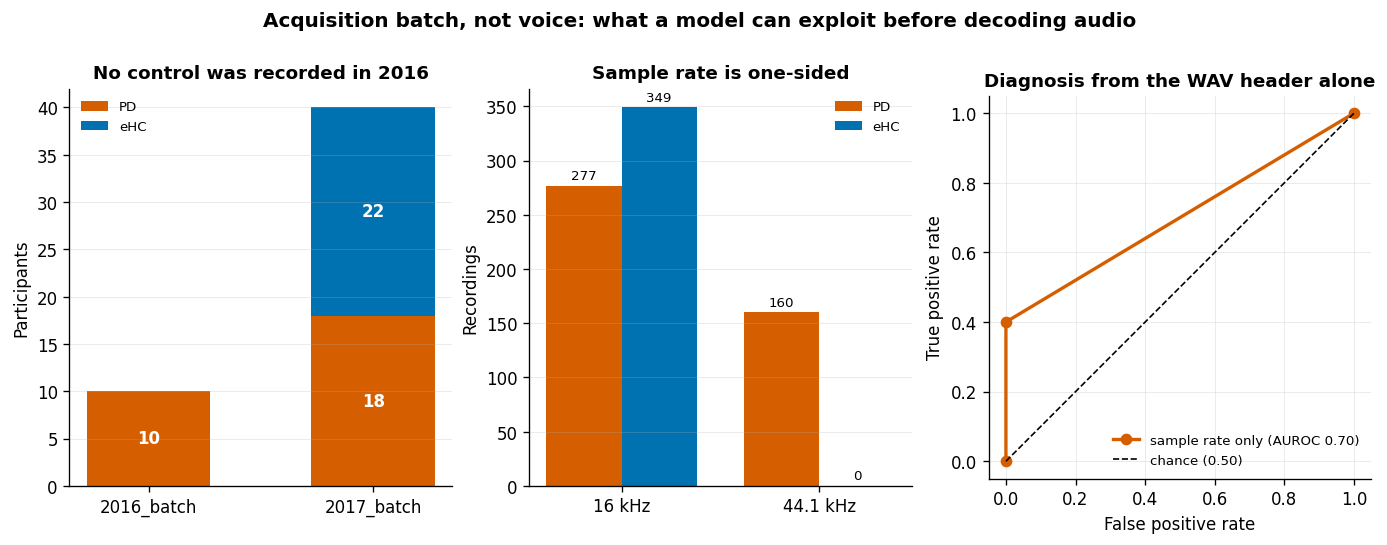

Participant-level AUROC from sample rate alone: 0.700

This is why every result is also reported on the batch-matched cohort (2017 only, 16 kHz): 18 PD vs 22 eHC.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.3))

batch_counts = (
    cohort.drop_duplicates(["subject_id", "batch"])
    .pivot_table(index="batch", columns="group", values="subject_id",
                 aggfunc="nunique", fill_value=0)
    .reindex(columns=["PD", "eHC"], fill_value=0)
)
bottom = np.zeros(len(batch_counts))
for group in ("PD", "eHC"):
    bars = axes[0].bar(
        batch_counts.index,
        batch_counts[group],
        bottom=bottom,
        color=V.GROUP_COLOURS[group],
        label=group,
        width=0.55,
    )
    axes[0].bar_label(bars, labels=[f"{v}" if v else "" for v in batch_counts[group]],
                      label_type="center", fontsize=10, color="white", fontweight="bold")
    bottom += batch_counts[group].to_numpy()
axes[0].set_ylabel("Participants")
axes[0].set_title("No control was recorded in 2016")
axes[0].legend(fontsize=8)
axes[0].grid(axis="x", visible=False)

rate_counts = (
    cohort.pivot_table(index="samplerate", columns="group", values="path",
                       aggfunc="count", fill_value=0)
    .reindex(columns=["PD", "eHC"], fill_value=0)
)
x = np.arange(len(rate_counts))
for i, group in enumerate(("PD", "eHC")):
    bars = axes[1].bar(x + (i - 0.5) * 0.38, rate_counts[group], 0.38,
                       color=V.GROUP_COLOURS[group], label=group)
    axes[1].bar_label(bars, fontsize=8, padding=2)
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{r/1000:g} kHz" for r in rate_counts.index])
axes[1].set_ylabel("Recordings")
axes[1].set_title("Sample rate is one-sided")
axes[1].legend(fontsize=8)
axes[1].grid(axis="x", visible=False)

from sklearn.metrics import roc_curve, roc_auc_score  # noqa: E402

by_participant = cohort.groupby("subject_id").agg(
    label=("label", "max"), rate=("samplerate", "max"), age=("age", "first"),
    sex=("sex", "first"),
)
header_only = (by_participant["rate"] == 44_100).astype(int)
fpr, tpr, _ = roc_curve(by_participant["label"], header_only)
auc_header = roc_auc_score(by_participant["label"], header_only)
axes[2].plot(fpr, tpr, marker="o", color="#D55E00", linewidth=2,
             label=f"sample rate only (AUROC {auc_header:.2f})")
axes[2].plot([0, 1], [0, 1], color="black", linestyle="--", linewidth=1,
             label="chance (0.50)")
axes[2].set_xlabel("False positive rate")
axes[2].set_ylabel("True positive rate")
axes[2].set_title("Diagnosis from the WAV header alone")
axes[2].legend(fontsize=8, loc="lower right")
axes[2].set_aspect("equal")

fig.suptitle(
    "Acquisition batch, not voice: what a model can exploit before decoding audio",
    fontsize=12, fontweight="bold", y=1.03,
)
V.save_fig(
    fig,
    "fig05_batch_confound",
    "The 2016 campaign recorded patients only, at 44.1 kHz; the 2017 campaign "
    "recorded the remaining patients and all controls at 16 kHz. Sample rate "
    f"alone reaches participant-level AUROC {auc_header:.2f}.",
)
plt.show()

print(f"Participant-level AUROC from sample rate alone: {auc_header:.3f}")
print(
    "\nThis is why every result is also reported on the batch-matched cohort "
    "(2017 only, 16 kHz): 18 PD vs 22 eHC."
)

In [9]:
audio.to_parquet(ROOT / "data" / "processed" / "audio_stats.parquet", index=False)
print("wrote data/processed/audio_stats.parquet")

wrote data/processed/audio_stats.parquet
